In [102]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


Hacemos el modelo para predecir 30 dias de temperatura usando los 90 dias anteriose como referencia

In [113]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = r"C:\Users\Mi Chelsy\Desktop\IA\IA\1ERPARCIAL"
TRAIN_CSV = os.path.join(DATA_DIR, "DailyDelhiClimateTrain.csv")
TEST_CSV = os.path.join(DATA_DIR, "DailyDelhiClimateTest.csv")

TARGET_COL = "meantemp"  # Temperatura media como objetivo
LOOKBACK = 90            # Días de contexto histórico
HORIZON = 30             # Días a predecir


Preparamos los datos de entrenmito y preuba para un modelo de series temporales, mean_X, std_X, mean_y, std_y hacemos solo con los datos de entrenamiento para evitar que información del test contamine
normalizamos los datos listos para entenar

In [115]:
# Cargar datos
df_train = pd.read_csv(TRAIN_CSV, parse_dates=["date"])
df_test = pd.read_csv(TEST_CSV, parse_dates=["date"])

print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")
# Combinar y ordenar por fecha
df_train["split"] = "train"
df_test["split"] = "test"
df = pd.concat([df_train, df_test], ignore_index=True)
df = df.sort_values("date").reset_index(drop=True).set_index("date")

# Selección de características
numeric_cols = [c for c in df.columns if c not in ["split"]]
if TARGET_COL not in numeric_cols:
    raise ValueError(f"La columna objetivo '{TARGET_COL}' no está en el CSV. Columnas")

# Menejo de valores faltantes
df[numeric_cols] = df[numeric_cols].interpolate(method="time")
df[numeric_cols] = df[numeric_cols].ffill().bfill()


# Añadir características de estacionalidad
doy = df.index.dayofyear.values
df["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
df["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)

# Características finales
feature_cols = [c for c in df.columns if c not in ["split"]]
if TARGET_COL not in feature_cols:
    feature_cols.append(TARGET_COL)

print(f"\nCaracterísticas utilizadas: {feature_cols}")

# Escalado sin fuga de datos
train_mask = (df["split"] == "train")
train_end_iloc = np.where(train_mask.values)[0][-1] + 1

X_all = df[feature_cols].values.astype(np.float32)
y_all = df[TARGET_COL].values.astype(np.float32).reshape(-1, 1)

# Calcular estadísticos solo con datos de entrenamiento
mean_X = X_all[:train_end_iloc].mean(axis=0)
std_X = X_all[:train_end_iloc].std(axis=0, ddof=0)
std_X[std_X == 0] = 1.0

mean_y = y_all[:train_end_iloc].mean(axis=0)
std_y = y_all[:train_end_iloc].std(axis=0, ddof=0)
std_y[std_y == 0] = 1.0

# Normalizar todos los datos
X_scaled = ((X_all - mean_X) / std_X).astype(np.float32)
y_scaled = ((y_all - mean_y) / std_y).astype(np.float32).squeeze(-1)

Train shape: (1462, 5), Test shape: (114, 5)

Características utilizadas: ['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'sin_doy', 'cos_doy']


shufflea mantiene orden temporal
convertimos una serie temporal en un formato de ventana deslizante para que nuestro MLP pueda aprender patrones temporales

Permite que mi red neuronal aprenda patrones pasados para lograr predecir valores futuros

Nos muestra:
x_train numero de muestras de netrenamiento, caracteristicas entrenadas
y_train numero de muestras de netrenamiento, dias futuros 

In [117]:
def prepare_mlp_data(X, y, lookback, horizon):
    X_mlp, y_mlp = [], []
    for i in range(len(X) - lookback - horizon + 1):
        X_flat = X[i:i+lookback].flatten()
        y_target = y[i+lookback:i+lookback+horizon]
        X_mlp.append(X_flat)
        y_mlp.append(y_target)
    return np.array(X_mlp), np.array(y_mlp)

# Prepararmos
X_mlp, y_mlp = prepare_mlp_data(X_scaled, y_scaled, LOOKBACK, HORIZON)

# Dividimos
train_size = int(0.7 * len(X_mlp))
val_size = int(0.15 * len(X_mlp))

X_train, y_train = X_mlp[:train_size], y_mlp[:train_size]
X_val, y_val = X_mlp[train_size:train_size+val_size], y_mlp[train_size:train_size+val_size]
X_test, y_test = X_mlp[train_size+val_size:], y_mlp[train_size+val_size:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (1019, 540), y_train: (1019, 30)
X_val: (218, 540), y_val: (218, 30)
X_test: (220, 540), y_test: (220, 30)


In [ ]:
D_in = X_train.shape[1] 
H = 128 
D_out = HORIZON 

def build_model(D_in=D_in, H=H, D_out=D_out):
    """Construye un modelo MLP simple"""
    return nn.Sequential(
        nn.Linear(D_in, H),
        nn.ReLU(),
        nn.Linear(H, H),
        nn.ReLU(),
        nn.Linear(H, D_out)
    )

model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(f"Modelo MLP creado:")
print(model)
print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

Modelo MLP creado:
Sequential(
  (0): Linear(in_features=540, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=30, bias=True)
)
Parámetros: 89,630


esta listo para entrenar y predecir 30 dis futuros con datos de 18 dia pasadso

In [ ]:
class MLPDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MLPDataset(X_train, y_train)
val_dataset = MLPDataset(X_val, y_val)
test_dataset = MLPDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
def fit(model, train_loader, val_loader, optimizer, epochs=EPOCHS, early_stopping=10):
    """Función de entrenamiento con early stopping"""
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validación
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Guardar mejor modelo
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping:
            print(f"Early stopping en época {epoch+1}")
            break
        
        if (epoch + 1) % 10 == 0:
            print(f"Época {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    return train_losses, val_losses

In [ ]:
train_losses, val_losses = fit(model, train_loader, val_loader, optimizer)
model.load_state_dict(torch.load('best_model.pth'))

Época 10/60 - Train Loss: 0.0539, Val Loss: 0.2354
Early stopping en época 11


<All keys matched successfully>

In [ ]:
model.eval()
test_preds = []
test_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        test_preds.append(y_pred.numpy())
        test_true.append(y_batch.numpy())

test_preds = np.concatenate(test_preds)
test_true = np.concatenate(test_true)

# Convertir a escala original
test_preds_original = test_preds * std_y + mean_y
test_true_original = test_true * std_y + mean_y

# Métricas
mae = mean_absolute_error(test_true_original.flatten(), test_preds_original.flatten())
rmse = np.sqrt(mean_squared_error(test_true_original.flatten(), test_preds_original.flatten()))

print(f"MAE en test: {mae:.3f}°C")
print(f"RMSE en test: {rmse:.3f}°C")


MAE en test: 2.349°C
RMSE en test: 2.766°C


In [ ]:
last_sequence = X_scaled[-LOOKBACK:].flatten()
last_sequence = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0)

model.eval()
with torch.no_grad():
    future_pred = model(last_sequence).numpy()

future_pred_original = future_pred * std_y + mean_y

# Fechas futuras
last_date = df.index[-1]
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=HORIZON, freq="D")

print("Predicciones para los próximos 30 días:")
for i, (date, temp) in enumerate(zip(future_dates, future_pred_original[0])):
    print(f"{date.strftime('%Y-%m-%d')}: {temp:.2f}°C")


Predicciones para los próximos 30 días:
2017-04-25: 32.43°C
2017-04-26: 32.80°C
2017-04-27: 31.98°C
2017-04-28: 32.86°C
2017-04-29: 32.48°C
2017-04-30: 33.27°C
2017-05-01: 33.16°C
2017-05-02: 32.25°C
2017-05-03: 33.07°C
2017-05-04: 33.65°C
2017-05-05: 33.02°C
2017-05-06: 33.33°C
2017-05-07: 34.24°C
2017-05-08: 33.80°C
2017-05-09: 32.90°C
2017-05-10: 33.84°C
2017-05-11: 33.25°C
2017-05-12: 33.29°C
2017-05-13: 33.46°C
2017-05-14: 34.97°C
2017-05-15: 34.03°C
2017-05-16: 33.59°C
2017-05-17: 34.56°C
2017-05-18: 33.61°C
2017-05-19: 32.57°C
2017-05-20: 32.64°C
2017-05-21: 34.18°C
2017-05-22: 31.65°C
2017-05-23: 33.53°C
2017-05-24: 33.71°C


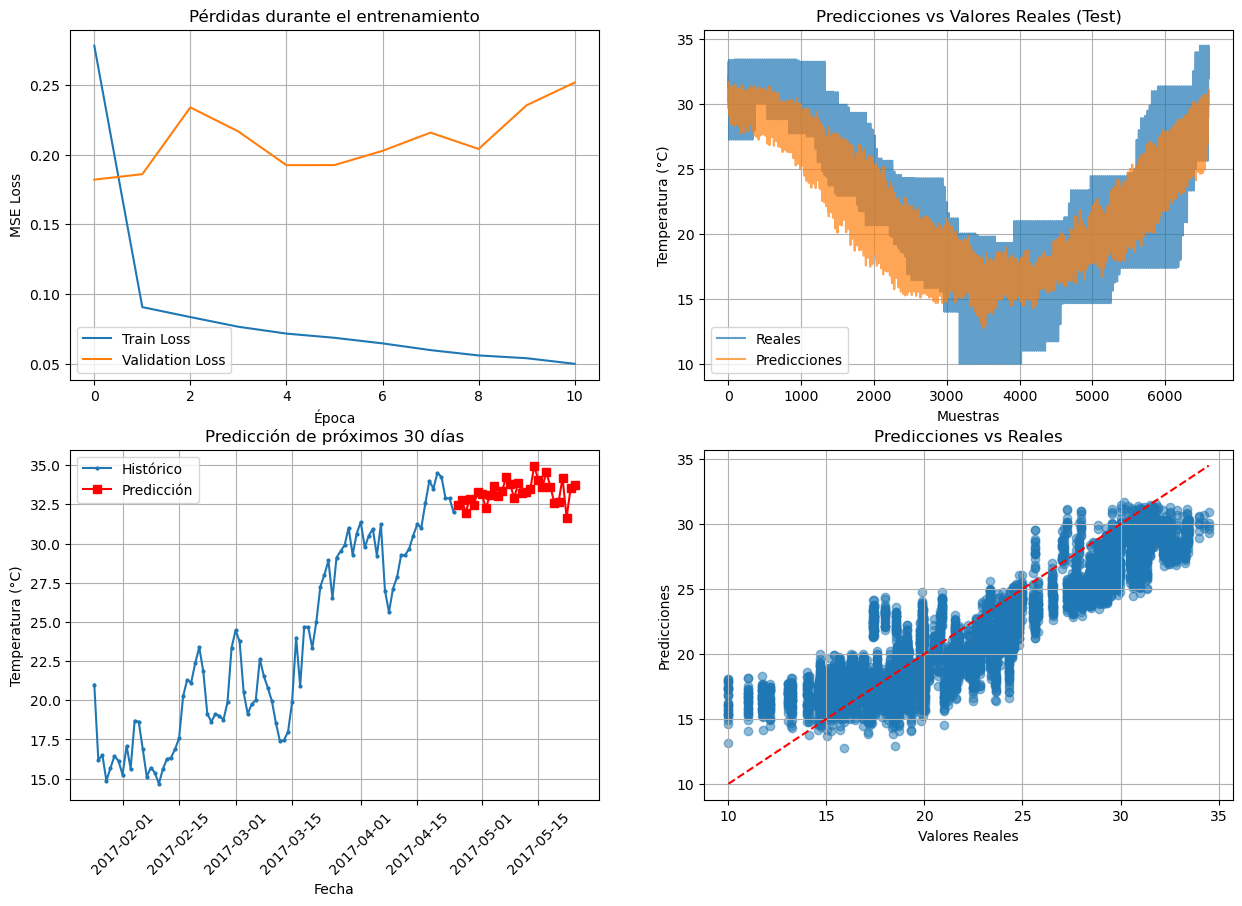

In [ ]:
plt.figure(figsize=(15, 10))

# Pérdidas
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Pérdidas durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# Predicciones vs Reales
plt.subplot(2, 2, 2)
plt.plot(test_true_original.flatten(), label='Reales', alpha=0.7)
plt.plot(test_preds_original.flatten(), label='Predicciones', alpha=0.7)
plt.title('Predicciones vs Valores Reales (Test)')
plt.xlabel('Muestras')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)

# Predicción futura
plt.subplot(2, 2, 3)
last_90_days = df[TARGET_COL].values[-90:]
last_90_dates = df.index[-90:]
plt.plot(last_90_dates, last_90_days, label='Histórico', marker='o', markersize=2)
plt.plot(future_dates, future_pred_original[0], label='Predicción', marker='s', color='red')
plt.title('Predicción de próximos 30 días')
plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Scatter plot
plt.subplot(2, 2, 4)
plt.scatter(test_true_original.flatten(), test_preds_original.flatten(), alpha=0.5)
min_val = min(test_true_original.min(), test_preds_original.min())
max_val = max(test_true_original.max(), test_preds_original.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title('Predicciones vs Reales')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.grid(True)
